<a href="https://colab.research.google.com/github/Bhargavimarathe/INTERNSHIP-2026/blob/main/daily_codes/week7/poly_reg_complete6-8july.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# data -> Salary_data.csv

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df= pd.read_csv('Salary_Data.csv')
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [8]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [10]:
# check for linearity

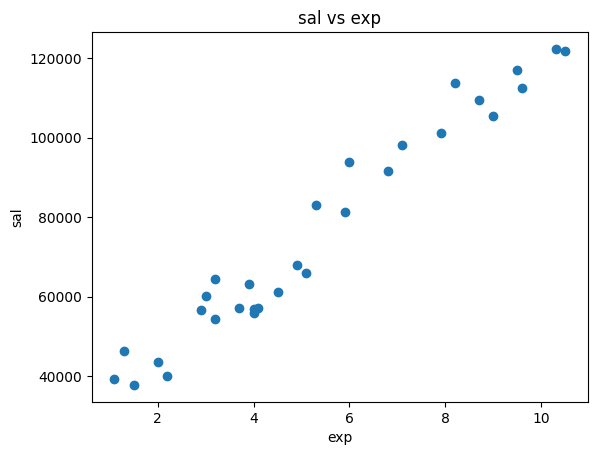

In [11]:
plt.title("sal vs exp")
plt.xlabel("exp")
plt.ylabel("sal")
plt.scatter(df["YearsExperience"], df["Salary"])

In [12]:
x= df[['YearsExperience']]
y= df['Salary']

In [13]:
y;

In [14]:
# cross val

In [15]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(x,y,random_state=0, test_size=0.25)

In [16]:
x_train.shape, y_train.shape, x_test.shape,y_test.shape

((22, 1), (22,), (8, 1), (8,))

In [17]:
# build the model

In [18]:
from sklearn.linear_model import LinearRegression

lr= LinearRegression()

lr.fit(x_train, y_train)

LinearRegression()

In [19]:
# val of m
lr.coef_

array([9379.71049195])

In [20]:
# val of c
lr.intercept_

np.float64(26986.691316737248)

In [21]:
# compare act and pred

In [22]:
y_pred= lr.predict(x_test)

In [23]:
pd.DataFrame({'actual': y_test,
              'pred': y_pred})

,actual,pred
2,37731.0,41056.257055
28,122391.0,123597.709384
13,57081.0,65443.504334
10,63218.0,63567.562235
26,116969.0,116093.940990
24,109431.0,108590.172597
27,112635.0,117031.912039
11,55794.0,64505.533285


In [24]:
# plot the best fit line on previous scatter chart

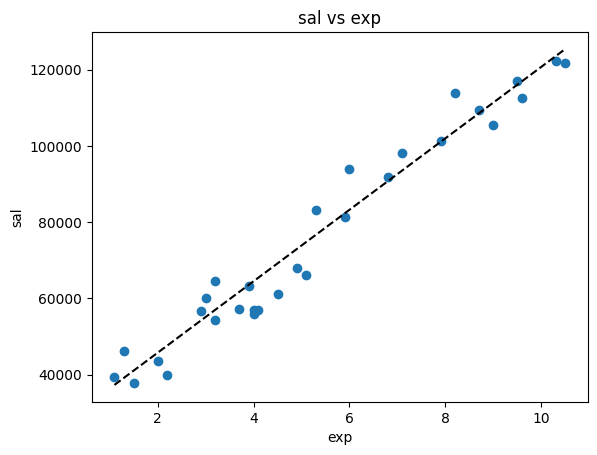

In [25]:
plt.title("sal vs exp")
plt.xlabel("exp")
plt.ylabel("sal")
plt.scatter(df["YearsExperience"], df["Salary"])
plt.plot(x, lr.predict(x), color='black', ls='--')
plt.show()

In [26]:
from sklearn.metrics import mean_absolute_error

In [27]:
mean_absolute_error(y_test, y_pred)

3508.5455930660555

In [28]:
from sklearn.metrics import r2_score

In [29]:
# create polynomial fratures

In [30]:
from sklearn.preprocessing import PolynomialFeatures

In [31]:
poly= PolynomialFeatures(degree=6)

In [32]:
x_poly= poly.fit_transform(x)

In [33]:
x_poly

array([[1.00000000e+00, 1.10000000e+00, 1.21000000e+00, 1.33100000e+00,
        1.46410000e+00, 1.61051000e+00, 1.77156100e+00],
       [1.00000000e+00, 1.30000000e+00, 1.69000000e+00, 2.19700000e+00,
        2.85610000e+00, 3.71293000e+00, 4.82680900e+00],
       [1.00000000e+00, 1.50000000e+00, 2.25000000e+00, 3.37500000e+00,
        5.06250000e+00, 7.59375000e+00, 1.13906250e+01],
       [1.00000000e+00, 2.00000000e+00, 4.00000000e+00, 8.00000000e+00,
        1.60000000e+01, 3.20000000e+01, 6.40000000e+01],
       [1.00000000e+00, 2.20000000e+00, 4.84000000e+00, 1.06480000e+01,
        2.34256000e+01, 5.15363200e+01, 1.13379904e+02],
       [1.00000000e+00, 2.90000000e+00, 8.41000000e+00, 2.43890000e+01,
        7.07281000e+01, 2.05111490e+02, 5.94823321e+02],
       [1.00000000e+00, 3.00000000e+00, 9.00000000e+00, 2.70000000e+01,
        8.10000000e+01, 2.43000000e+02, 7.29000000e+02],
       [1.00000000e+00, 3.20000000e+00, 1.02400000e+01, 3.27680000e+01,
        1.04857600e+02, 3

In [34]:
# cross val, linear reg model, r2 score

In [35]:
x_train, x_test, y_train, y_test= train_test_split(x_poly, y, random_state=0)

In [36]:
lr= LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [37]:
y_pred= lr.predict(x_test)

In [38]:
r2_score(y_test, y_pred)

0.9530506119354363

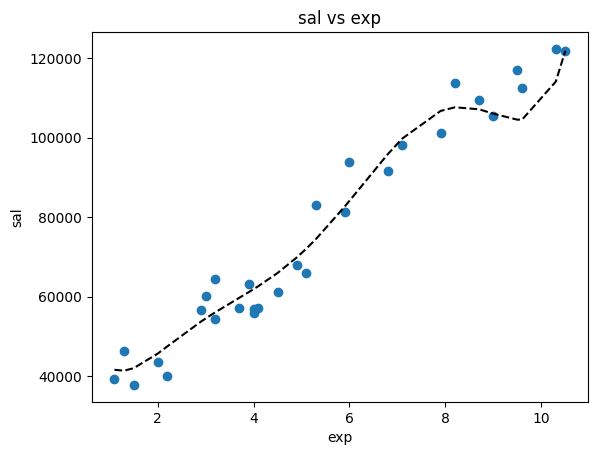

In [39]:
plt.title("sal vs exp")
plt.xlabel("exp")
plt.ylabel("sal")
plt.scatter(df['YearsExperience'], df['Salary']);
plt.plot(x, lr.predict(x_poly), color = 'black', ls = '--');

In [40]:

# check for overfit

print("train:", lr.score(x_train, y_train))  # training acc
print("test:", lr.score(x_test, y_test)) # test acc

train: 0.9568085724298091
test: 0.9530506119354363
